In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Path to the Excel file
file_path = Path("../data/Datasets.xlsx")

# Load the Excel file
excel_file = pd.ExcelFile(file_path)

# Display all sheet names
print("Sheets in the Excel file:")
print(excel_file.sheet_names)

Sheets in the Excel file:
['Employee_Attrition', 'Recruitment', 'Resume_NLP', 'Recommendation', 'Helpdesk', 'Bug_Severity', 'Churn', 'Fraud', 'Resource', 'Performance']


In [14]:
# Load the Recruitment dataset
recruitment_df = pd.read_excel(
    file_path,
    sheet_name="Recruitment"
)

# Display the first 5 rows
recruitment_df.head()

,Candidate_ID,Position,Experience,Tech_Score,Interview,Status
0,C0001,DS,4,78,83,Hired
1,C0002,DS,6,99,63,Hired
2,C0003,SE,7,78,69,Rejected
3,C0004,SE,1,89,42,Rejected
4,C0005,QA,4,77,48,Pending


In [15]:
# Basic information
print("Dataset shape:", recruitment_df.shape)

print("\nColumn names:")
print(recruitment_df.columns.tolist())

print("\nData types:")
print(recruitment_df.dtypes)

print("\nMissing values:")
print(recruitment_df.isnull().sum())

print("\nDuplicate rows:", recruitment_df.duplicated().sum())

print("\nStatus distribution:")
print(recruitment_df["Status"].value_counts())

Dataset shape: (200, 6)

Column names:
['Candidate_ID', 'Position', 'Experience', 'Tech_Score', 'Interview', 'Status']

Data types:
Candidate_ID      str
Position          str
Experience      int64
Tech_Score      int64
Interview       int64
Status            str
dtype: object

Missing values:
Candidate_ID    0
Position        0
Experience      0
Tech_Score      0
Interview       0
Status          0
dtype: int64

Duplicate rows: 0

Status distribution:
Status
Rejected    69
Pending     68
Hired       63
Name: count, dtype: int64


In [16]:
# Summary statistics for numerical columns
display(recruitment_df.describe())

print("\nPosition distribution:")
print(recruitment_df["Position"].value_counts())

print("\nStatus percentages:")
print(
    recruitment_df["Status"].value_counts(normalize=True) * 100
)

,Experience,Tech_Score,Interview
count,200.000000,200.00000,200.00000
mean,4.665000,69.55500,68.99000
std,2.987878,17.81245,16.78986
min,0.000000,40.00000,41.00000
25%,2.000000,54.00000,55.75000
50%,5.000000,71.50000,69.50000
75%,7.000000,84.00000,81.25000
max,10.000000,100.00000,100.00000



Position distribution:
Position
QA    76
SE    68
DS    56
Name: count, dtype: int64

Status percentages:
Status
Rejected    34.5
Pending     34.0
Hired       31.5
Name: proportion, dtype: float64


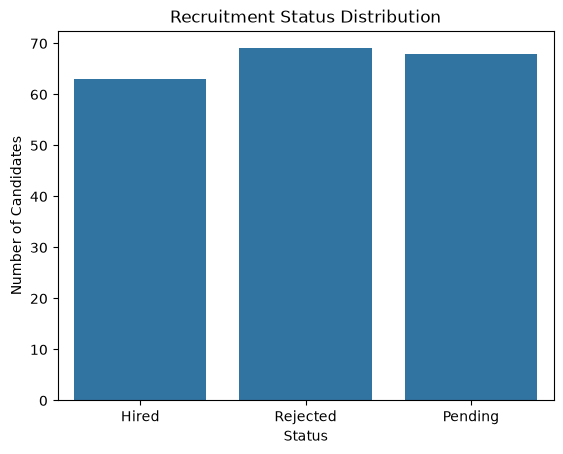

In [17]:
# Visualise the target distribution
sns.countplot(
    data=recruitment_df,
    x="Status"
)

plt.title("Recruitment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Candidates")
plt.show()

In [18]:
# Separate input features and target

X = recruitment_df.drop(columns=["Candidate_ID", "Status"])
y = recruitment_df["Status"]

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Feature columns:
['Position', 'Experience', 'Tech_Score', 'Interview']

Feature shape: (200, 4)
Target shape: (200,)

Target classes:
Status
Rejected    69
Pending     68
Hired       63
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features shape: (160, 4)
Testing features shape: (40, 4)

Training target distribution:
Status
Rejected    55
Pending     55
Hired       50
Name: count, dtype: int64

Testing target distribution:
Status
Rejected    14
Hired       13
Pending     13
Name: count, dtype: int64


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = [
    "Experience",
    "Tech_Score",
    "Interview"
]

categorical_features = [
    "Position"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Preprocessor created successfully")

Numerical features: ['Experience', 'Tech_Score', 'Interview']
Categorical features: ['Position']
Preprocessor created successfully


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions using the test data
y_pred_logistic = logistic_model.predict(X_test)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="macro",
    zero_division=0
)
logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="macro",
    zero_division=0
)
logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="macro",
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-score :", logistic_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

Logistic Regression Results
---------------------------
Accuracy : 0.625
Precision: 0.6162280701754386
Recall   : 0.6245421245421245
F1-score : 0.6103896103896104

Confusion Matrix:
[[13  0  0]
 [ 0  3 10]
 [ 0  5  9]]

Classification Report:
              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00        13
     Pending       0.38      0.23      0.29        13
    Rejected       0.47      0.64      0.55        14

    accuracy                           0.62        40
   macro avg       0.62      0.62      0.61        40
weighted avg       0.61      0.62      0.61        40



In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


In [24]:
# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Calculate evaluation metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="macro",
    zero_division=0
)
tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="macro",
    zero_division=0
)
tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="macro",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1-score :", tree_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, zero_division=0))

Decision Tree Results
---------------------
Accuracy : 0.625
Precision: 0.63003663003663
Recall   : 0.6300366300366301
F1-score : 0.6296296296296297

Confusion Matrix:
[[13  0  0]
 [ 0  6  7]
 [ 0  8  6]]

Classification Report:
              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00        13
     Pending       0.43      0.46      0.44        13
    Rejected       0.46      0.43      0.44        14

    accuracy                           0.62        40
   macro avg       0.63      0.63      0.63        40
weighted avg       0.63      0.62      0.62        40



In [25]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [26]:
# Make predictions
y_pred_forest = random_forest_model.predict(X_test)

# Calculate evaluation metrics
forest_accuracy = accuracy_score(y_test, y_pred_forest)
forest_precision = precision_score(
    y_test,
    y_pred_forest,
    average="macro",
    zero_division=0
)
forest_recall = recall_score(
    y_test,
    y_pred_forest,
    average="macro",
    zero_division=0
)
forest_f1 = f1_score(
    y_test,
    y_pred_forest,
    average="macro",
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", forest_accuracy)
print("Precision:", forest_precision)
print("Recall   :", forest_recall)
print("F1-score :", forest_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_forest))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_forest, zero_division=0))

Random Forest Results
---------------------
Accuracy : 0.525
Precision: 0.5277777777777778
Recall   : 0.5293040293040293
F1-score : 0.5282758620689655

Confusion Matrix:
[[13  0  0]
 [ 0  3 10]
 [ 0  9  5]]

Classification Report:
              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00        13
     Pending       0.25      0.23      0.24        13
    Rejected       0.33      0.36      0.34        14

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.53        40
weighted avg       0.52      0.53      0.52        40



In [27]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1_Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

classification_results = classification_results.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

classification_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Decision Tree,0.625,0.630037,0.630037,0.629630
1,Logistic Regression,0.625,0.616228,0.624542,0.610390
2,Random Forest,0.525,0.527778,0.529304,0.528276


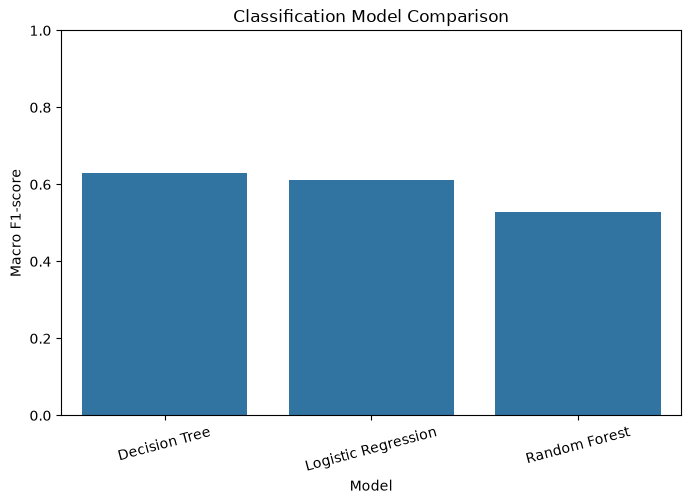

In [28]:
# Compare classification models using Macro F1-score
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1_Score"
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [29]:
import joblib
from pathlib import Path

# Create the models folder path
models_folder = Path("../models")
models_folder.mkdir(exist_ok=True)

# Save the best classification model
classification_model_path = models_folder / "best_classification_model.pkl"

joblib.dump(
    decision_tree_model,
    classification_model_path
)

print("Classification model saved successfully")
print("Saved location:", classification_model_path)

Classification model saved successfully
Saved location: ..\models\best_classification_model.pkl


In [30]:
# Load the employee dataset for regression
regression_df = pd.read_excel(
    file_path,
    sheet_name="Employee_Attrition"
)

# Display the first 5 rows
regression_df.head()

,Employee_ID,Age,Department,Role,Years,Salary,Job_Satisfaction,Performance,Attrition
0,E0001,25,HR,SE,4,179875,5,4,No
1,E0002,34,Engineering,Manager,15,57431,4,4,No
2,E0003,21,Support,Analyst,13,239147,5,2,No
3,E0004,22,Engineering,SE,3,220274,3,5,No
4,E0005,34,Support,SE,0,188314,4,2,No


In [31]:
print("Dataset shape:", regression_df.shape)

print("\nColumn names:")
print(regression_df.columns.tolist())

print("\nMissing values:")
print(regression_df.isnull().sum())

print("\nDuplicate rows:", regression_df.duplicated().sum())

Dataset shape: (200, 9)

Column names:
['Employee_ID', 'Age', 'Department', 'Role', 'Years', 'Salary', 'Job_Satisfaction', 'Performance', 'Attrition']

Missing values:
Employee_ID         0
Age                 0
Department          0
Role                0
Years               0
Salary              0
Job_Satisfaction    0
Performance         0
Attrition           0
dtype: int64

Duplicate rows: 0


In [32]:
# Summary statistics for regression data
display(regression_df.describe())

print("\nSalary statistics:")
print(regression_df["Salary"].describe())

,Age,Years,Salary,Job_Satisfaction,Performance
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,37.455000,7.520000,178290.090000,3.085000,3.070000
std,9.665146,4.815135,71509.092601,1.445066,1.361753
min,21.000000,0.000000,50221.000000,1.000000,1.000000
25%,29.000000,3.000000,117314.000000,2.000000,2.000000
50%,38.000000,8.000000,180310.500000,3.000000,3.000000
75%,45.250000,12.000000,240400.750000,4.000000,4.000000
max,55.000000,15.000000,299625.000000,5.000000,5.000000



Salary statistics:
count       200.000000
mean     178290.090000
std       71509.092601
min       50221.000000
25%      117314.000000
50%      180310.500000
75%      240400.750000
max      299625.000000
Name: Salary, dtype: float64


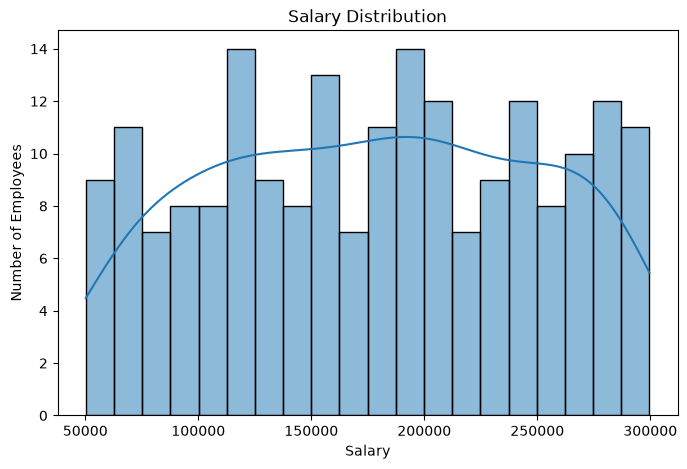

In [33]:
# Visualise salary distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=regression_df,
    x="Salary",
    bins=20,
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

In [46]:
# ==========================
# Feature Engineering
# ==========================

# Experience level based on years of service
regression_df["Experience_Level"] = pd.cut(
    regression_df["Years"],
    bins=[-1, 2, 5, 10, 15],
    labels=["Beginner", "Junior", "Mid", "Senior"]
)

# Combined performance score
regression_df["Performance_Index"] = (
    regression_df["Performance"] *
    regression_df["Job_Satisfaction"]
)

print("Feature engineering completed.")

Feature engineering completed.


In [47]:
# Recreate regression features after feature engineering

X_reg_fe = regression_df.drop(
    columns=["Employee_ID", "Salary"]
)

y_reg_fe = regression_df["Salary"]

print("Updated regression feature columns:")
print(X_reg_fe.columns.tolist())

print("\nFeature shape:", X_reg_fe.shape)
print("Target shape:", y_reg_fe.shape)

display(
    regression_df[
        [
            "Years",
            "Experience_Level",
            "Performance",
            "Job_Satisfaction",
            "Performance_Index"
        ]
    ].head()
)

Updated regression feature columns:
['Age', 'Department', 'Role', 'Years', 'Job_Satisfaction', 'Performance', 'Attrition', 'Experience_Level', 'Performance_Index']

Feature shape: (200, 9)
Target shape: (200,)


,Years,Experience_Level,Performance,Job_Satisfaction,Performance_Index
0,4,Junior,4,5,20
1,15,Senior,4,4,16
2,13,Senior,2,5,10
3,3,Junior,5,3,15
4,0,Beginner,2,4,8


In [49]:
X_train_reg_fe, X_test_reg_fe, y_train_reg_fe, y_test_reg_fe = train_test_split(
    X_reg_fe,
    y_reg_fe,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train_reg_fe.shape)
print("Testing features shape:", X_test_reg_fe.shape)

print("Training target shape:", y_train_reg_fe.shape)
print("Testing target shape:", y_test_reg_fe.shape)

Training features shape: (160, 9)
Testing features shape: (40, 9)
Training target shape: (160,)
Testing target shape: (40,)


In [50]:
# Updated preprocessing after feature engineering

reg_numerical_features_fe = [
    "Age",
    "Years",
    "Job_Satisfaction",
    "Performance",
    "Performance_Index"
]

reg_categorical_features_fe = [
    "Department",
    "Role",
    "Attrition",
    "Experience_Level"
]

reg_preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            reg_numerical_features_fe
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            reg_categorical_features_fe
        )
    ]
)

print("Updated numerical features:", reg_numerical_features_fe)
print("Updated categorical features:", reg_categorical_features_fe)
print("Feature-engineered preprocessor created successfully")

Updated numerical features: ['Age', 'Years', 'Job_Satisfaction', 'Performance', 'Performance_Index']
Updated categorical features: ['Department', 'Role', 'Attrition', 'Experience_Level']
Feature-engineered preprocessor created successfully


In [53]:
# Linear Regression with feature engineering
linear_regression_model_fe = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor_fe),
        ("regressor", LinearRegression())
    ]
)

# Decision Tree Regressor with feature engineering
decision_tree_regressor_fe = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor_fe),
        (
            "regressor",
            DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# Random Forest Regressor with feature engineering
random_forest_regressor_fe = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor_fe),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# Train all three models
linear_regression_model_fe.fit(X_train_reg_fe, y_train_reg_fe)
decision_tree_regressor_fe.fit(X_train_reg_fe, y_train_reg_fe)
random_forest_regressor_fe.fit(X_train_reg_fe, y_train_reg_fe)

print("All feature-engineered regression models trained successfully")

All feature-engineered regression models trained successfully


In [54]:
# Make predictions
y_pred_linear_fe = linear_regression_model_fe.predict(X_test_reg_fe)
y_pred_tree_fe = decision_tree_regressor_fe.predict(X_test_reg_fe)
y_pred_forest_fe = random_forest_regressor_fe.predict(X_test_reg_fe)

# Linear Regression metrics
linear_mae_fe = mean_absolute_error(y_test_reg_fe, y_pred_linear_fe)
linear_mse_fe = mean_squared_error(y_test_reg_fe, y_pred_linear_fe)
linear_rmse_fe = np.sqrt(linear_mse_fe)
linear_r2_fe = r2_score(y_test_reg_fe, y_pred_linear_fe)

# Decision Tree metrics
tree_mae_fe = mean_absolute_error(y_test_reg_fe, y_pred_tree_fe)
tree_mse_fe = mean_squared_error(y_test_reg_fe, y_pred_tree_fe)
tree_rmse_fe = np.sqrt(tree_mse_fe)
tree_r2_fe = r2_score(y_test_reg_fe, y_pred_tree_fe)

# Random Forest metrics
forest_mae_fe = mean_absolute_error(y_test_reg_fe, y_pred_forest_fe)
forest_mse_fe = mean_squared_error(y_test_reg_fe, y_pred_forest_fe)
forest_rmse_fe = np.sqrt(forest_mse_fe)
forest_r2_fe = r2_score(y_test_reg_fe, y_pred_forest_fe)

print("Feature-Engineered Regression Results")
print("-------------------------------------")

print("\nLinear Regression")
print("MAE :", linear_mae_fe)
print("RMSE:", linear_rmse_fe)
print("R²  :", linear_r2_fe)

print("\nDecision Tree Regressor")
print("MAE :", tree_mae_fe)
print("RMSE:", tree_rmse_fe)
print("R²  :", tree_r2_fe)

print("\nRandom Forest Regressor")
print("MAE :", forest_mae_fe)
print("RMSE:", forest_rmse_fe)
print("R²  :", forest_r2_fe)

Feature-Engineered Regression Results
-------------------------------------

Linear Regression
MAE : 63259.14852182084
RMSE: 75580.11020101894
R²  : -0.22865897729224383

Decision Tree Regressor
MAE : 61647.9700283199
RMSE: 80084.21518009336
R²  : -0.37946334312363805

Random Forest Regressor
MAE : 58797.28660791431
RMSE: 70301.5649363664
R²  : -0.06303191142798314


In [55]:
regression_results_fe = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae_fe,
        tree_mae_fe,
        forest_mae_fe
    ],
    "MSE": [
        linear_mse_fe,
        tree_mse_fe,
        forest_mse_fe
    ],
    "RMSE": [
        linear_rmse_fe,
        tree_rmse_fe,
        forest_rmse_fe
    ],
    "R2_Score": [
        linear_r2_fe,
        tree_r2_fe,
        forest_r2_fe
    ]
})

regression_results_fe = regression_results_fe.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

regression_results_fe

,Model,MAE,MSE,RMSE,R2_Score
0,Random Forest Regressor,58797.286608,4.942310e+09,70301.564936,-0.063032
1,Linear Regression,63259.148522,5.712353e+09,75580.110201,-0.228659
2,Decision Tree Regressor,61647.970028,6.413482e+09,80084.215180,-0.379463


In [56]:
# Save the best feature-engineered regression model

regression_model_path = models_folder / "best_regression_model.pkl"

joblib.dump(
    random_forest_regressor_fe,
    regression_model_path
)

print("Regression model saved successfully")
print("Saved location:", regression_model_path)

Regression model saved successfully
Saved location: ..\models\best_regression_model.pkl


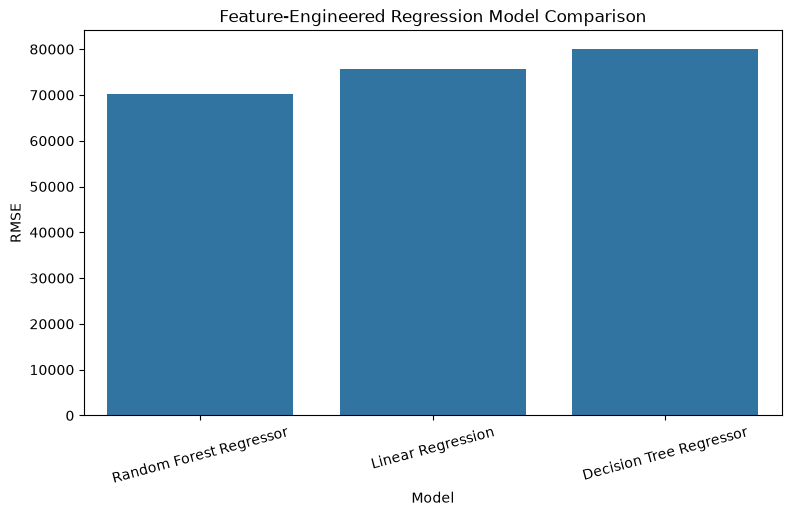

In [57]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_results_fe,
    x="Model",
    y="RMSE"
)

plt.title("Feature-Engineered Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()